# Exercise Project 1 

Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

#### Target variable -- Sales price

|Step|Description|
|---|---|
|1| Clean the data|
|2| Define the x and y variables.|
|3| Train/test splitting|
|4| Model Initialization|
|5| Obtain the intercept|
|6| Retrieve test predictions|
|7| Determine if prediction line is linear|
|8| Test result|
|9| Obtain error metrics|
|10| Plotting prediction to the distribution|
|11| Plotting linplot indepedently|

---

### Code

In [584]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from skfeature.function.similarity_based import fisher_score
from scipy import stats
from sklearn.preprocessing import OneHotEncoder

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")

# Initial look
df.head(10)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0
5,1,373,46,470000,10009.0,SI,1944.0,3132.0,2440.0,440.0,2000.0,1.0,2.0,2.0,40.613137,-74.125878,4.0,K4,81.0
6,1,373,46,474000,10009.0,SI,1944.0,3132.0,2440.0,440.0,2000.0,1.0,2.0,2.0,40.613137,-74.125878,4.0,K4,81.0
7,1,374,8,1050000,10009.0,BK,1899.0,1400.0,2700.0,2700.0,0.0,3.0,3.0,3.0,40.678077,-73.999960,2.0,C0,126.0
8,1,375,30,330000,10009.0,MN,1902.0,3082.0,17556.0,17556.0,0.0,19.0,19.0,6.0,40.722625,-73.977788,2.0,C6,123.0
9,1,376,5,425000,10009.0,MN,1900.0,3772.0,15086.0,14086.0,1000.0,22.0,24.0,6.0,40.723737,-73.978783,2.0,C6,125.0


##### Cleaning

In [585]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

In [586]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of these are probably trivial 200/34000 = .5% of the data. 
# The dataset isn't timeseries either, so we're not compromising the dataset by deleting rows.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [587]:
# Dropping nan values.
df = df.dropna()

##### Filtering Data

In [588]:
# Filtering out any rows which may be for commercial uses. Drops ~6k rows.
# A hefty price, but worth-it, considering commercial buildings are likely outliers and unrelated.
df[df['comarea'] > 0].shape


# Dropping columns that initially can be seen as redundant or otherwise not useful.
df = df.drop(["borough_x", "block", "lot",'latitude','longitude'], axis=1)


<Axes: xlabel='sale_price', ylabel='Count'>

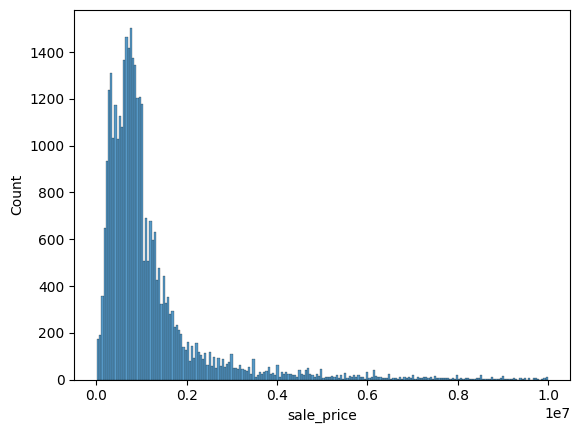

In [589]:
# Let's take a look at the target variable's distribution
sns.histplot(df, x='sale_price')

# VERY skewed. Let's cut some of that off. 

13734


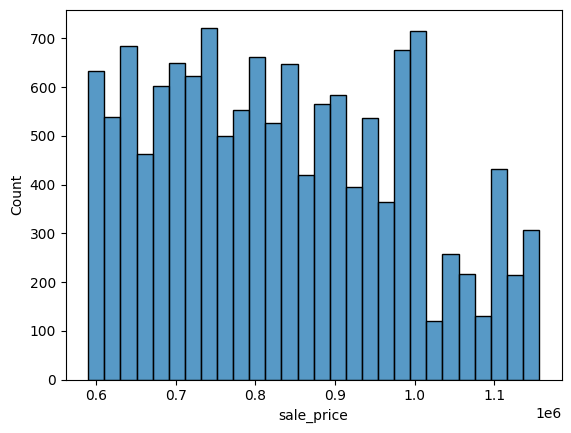

In [590]:

# Instead of df.query(), I'll be using a multi-filter approach. 
df = df[
    (df['sale_price'] >= df['sale_price'].quantile(q=0.30)) &
    (df['sale_price'] <= df['sale_price'].quantile(q=0.70))
    ]

# Let's take a look at the target variable's distribution
sns.histplot(df, x='sale_price')

# MUCH better. It isn't following a perfect bell-curve, but
# it's probably good enough.


# Let's check how many rows we have left.
print(df.shape[0])

In [591]:
df.head(5)

,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,landuse,bldgclass,building_age
4,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,2.0,C6,105.0
7,1050000,10009.0,BK,1899.0,1400.0,2700.0,2700.0,0.0,3.0,3.0,3.0,2.0,C0,126.0
18,650000,10009.0,MN,1900.0,2272.0,10800.0,10100.0,700.0,19.0,20.0,6.0,2.0,C6,125.0
19,915000,10009.0,MN,1950.0,2271.0,8720.0,8720.0,0.0,12.0,12.0,5.0,2.0,C6,75.0
21,685000,10009.0,SI,1950.0,3498.0,928.0,928.0,0.0,1.0,1.0,1.0,1.0,A2,75.0


##### Selecting Features
Continous/Ordinal Features


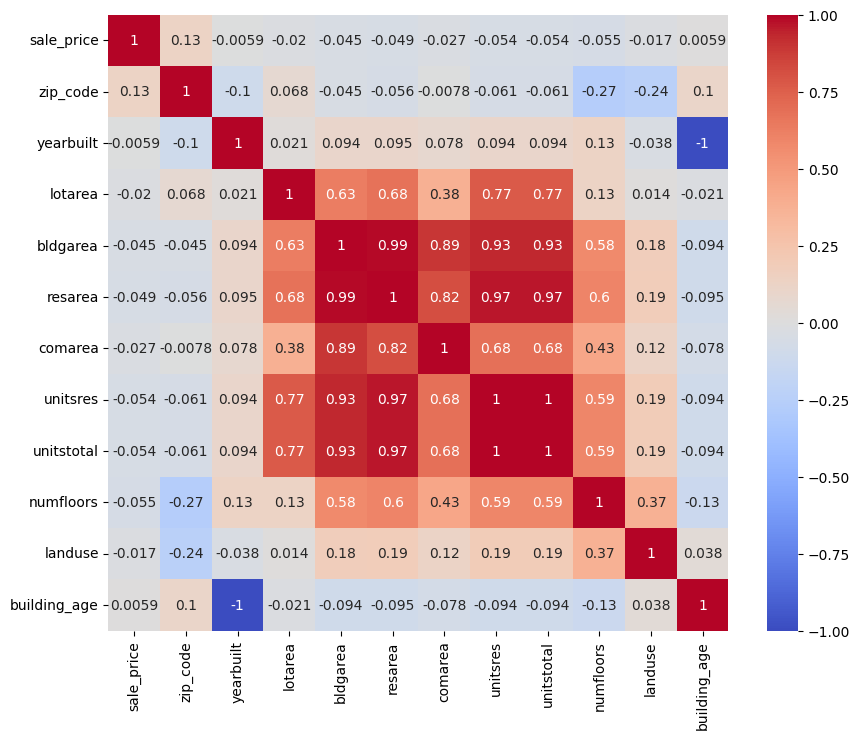

In [592]:
# METHOD 1: CORRELATION HEATMAP
correlations = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm')


# sale_price corrolates weakly, but somewhat with the following columns:
# zip_code
# bldg_area
# unitsres
# numfloors

# REASONING
# Pearson checks for LINEAR relationships. 
# PEARSON: Continuous target --> contiuous/binary feature cases
# FISHER: Categorical target --> continuous feature cases
# SELECTKBEST: Categorical target --> discrete non-negative feature cases.


# Dropping non-effective feature columns.
df = df[['sale_price','zip_code','bldgarea','unitsres','numfloors','borough_y','bldgclass']]


#### 

Categorical Features

In [593]:
# We have two categorical values in our dataset that we should look at.
# This code turns categorical variables into separate, binary columns.
# NOTE: this will create a ton of columns, an that's ok! Let's let the
# heatmap do all the work for us.

# The columns we wish to convert to binary columns.
categorical_columns = ["borough_y","bldgclass"]

for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


<Axes: >

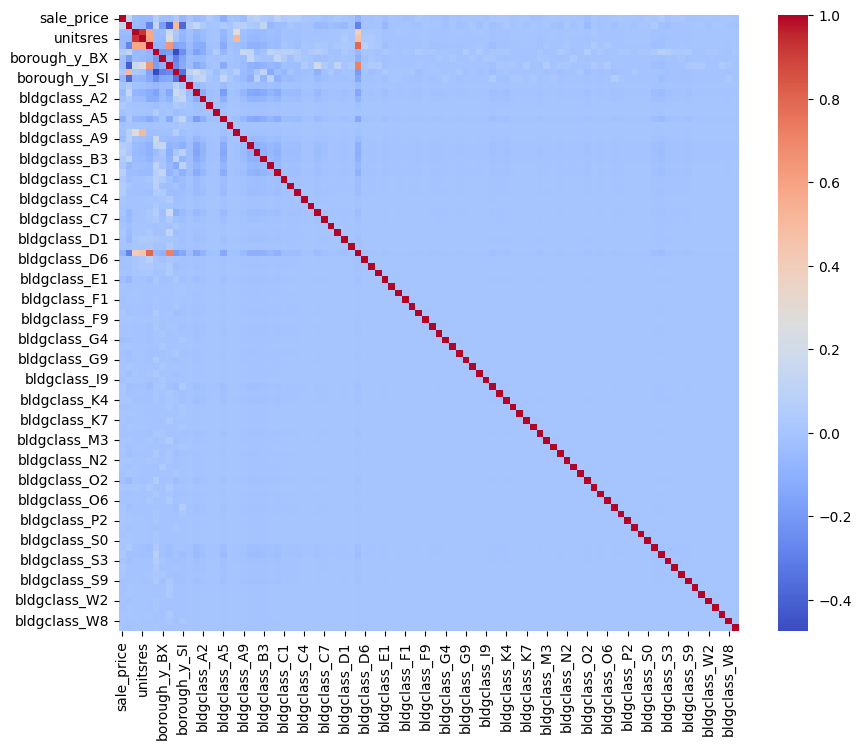

In [594]:
# METHOD 1: CORRELATION HEATMAP
correlations = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlations, cmap='coolwarm')

# Two observations:
# bldgclass_D4 appears to correlate with sale_price.
# We can't really see the borough results well, it needs to be looked at closer.


<Axes: >

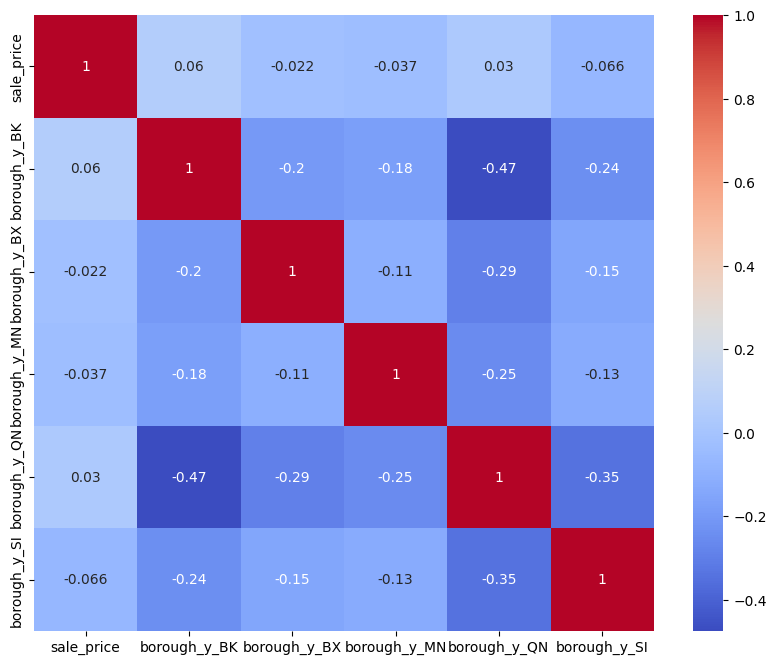

In [595]:
# Let's create a separate dataframe with only the binary borough-type
# columns and the target variable

# Filtering
df_bclass = df[['sale_price',
         'borough_y_BK',
         'borough_y_BX',
         'borough_y_MN',
         'borough_y_QN',
         'borough_y_SI'
           ]]


# Heatmap
correlations = df_bclass.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# Observation:
# borough_y_BK seems to be a viable predictor (for what it's worth, anyways. All of these
# correlations are quite weak. At this point, I would be thinking of a different model, perhaps.)

Conclusion:

We're going to keep the following features + the target variable:

|columns|
|---|
|'sale_price'|
|'zip_code'|
|'bldgarea'|
|'unitsres'|
|'numfloors'|
|'borough_y'|
|'bldgclass_D4'|


In [596]:
# Now we have obtained all of the most correlating features, let's filter them all into one dataset.
df = df[["sale_price",'zip_code','bldgarea','numfloors','borough_y_BK','bldgclass_D4']]
df.head(5)

,sale_price,zip_code,bldgarea,numfloors,borough_y_BK,bldgclass_D4
4,655000,10009.0,17990.0,5.0,0,0
7,1050000,10009.0,2700.0,3.0,1,0
18,650000,10009.0,10800.0,6.0,0,0
19,915000,10009.0,8720.0,5.0,0,0
21,685000,10009.0,928.0,1.0,0,0


<Axes: >

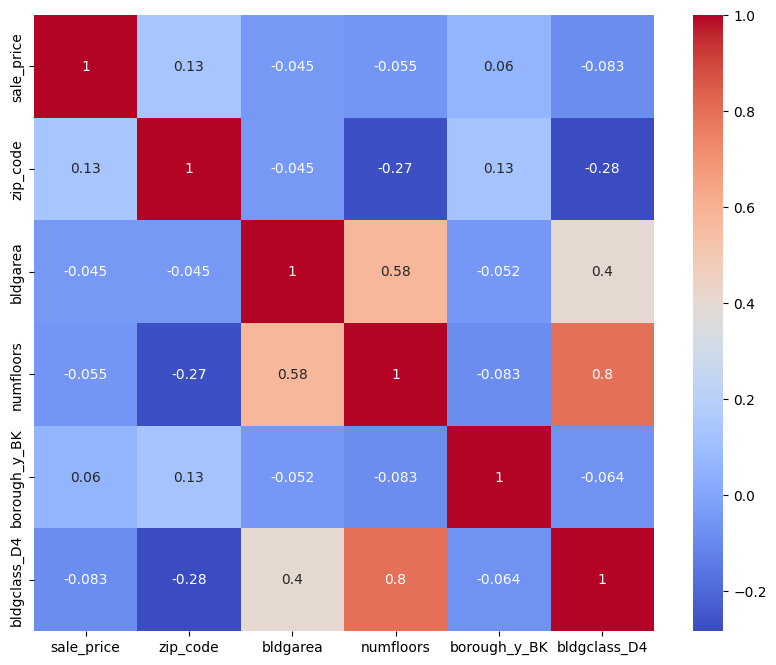

In [597]:
# Final Correlation Check. 
correlations = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# Much better. I'm not hopeful how it will hold up for my first model but let's try it. 

---

### Linear Regression 


In [598]:
# Defining dependent, independent variables.
X = df.drop("sale_price", axis=1)
y = df['sale_price']

# train/test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Initalization
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [599]:
intercept = lm.intercept_

# this will be a list of variables (to support multiple linear regression)
# the slopes of the different variables in the linear regression formula
coefs = lm.coef_

# if you want to have a nice table of different variable values:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coeff'])
cdf.round(2)

,Coeff
zip_code,34.22
bldgarea,-0.03
numfloors,2222.13
borough_y_BK,14521.28
bldgclass_D4,-41766.19


In [600]:
predictions = lm.predict(X_test)

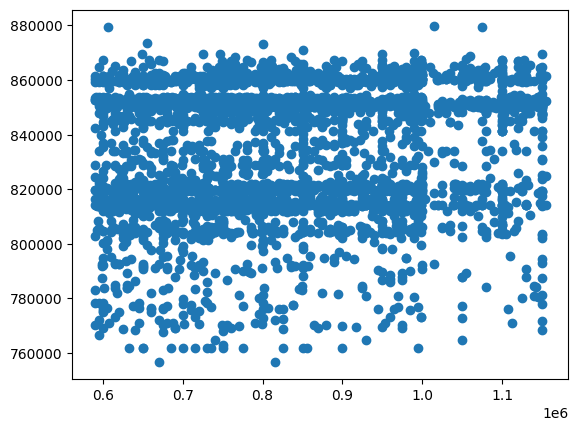

In [601]:
# these values follow a line = good predictions
plt.scatter(y_test, predictions)
plt.show()

# As expected, a vague line exists, but it likely wont be useful.
# They roughly follow what appears to be TWO lines! Interesting.


In [602]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))


# CONCLUSION:
# the linear regression method is not really a great predictor for sale_price.

MAE
125123.8 $

MSE
22033175383.22 $^2

RMSE:
148435.76 $

R-squared:
0.02
